# EDA

## 1. Data Loading and Initial Setup

This section loads the required Python libraries and reads all provided CSV files into pandas DataFrames. We use `Path` to define the data directory so that file paths are easier to manage and less error-prone.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("data")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
complaints = pd.read_csv(DATA_DIR / "chief_complaints.csv")
history = pd.read_csv(DATA_DIR / "patient_history.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train:", train.shape)
print("test:", test.shape)
print("complaints:", complaints.shape)
print("history:", history.shape)
print("sample_submission:", sample_submission.shape)

train: (80000, 40)
test: (20000, 37)
complaints: (100000, 3)
history: (100000, 26)
sample_submission: (20000, 2)


## 2. Data Integrity and Merge Check

In [ ]:
#Train-Test Column Difference

train_cols = set(train.columns)
test_cols = set(test.columns)

train_only_cols = sorted(train_cols - test_cols)
test_only_cols = sorted(test_cols - train_cols)

print("Columns only in train:")
print(train_only_cols)

print("\nColumns only in test:")
print(test_only_cols)

Columns only in train:
['disposition', 'ed_los_hours', 'triage_acuity']

Columns only in test:
[]


The training set contains three columns that are not present in the test set: `triage_acuity`, `disposition`, and `ed_los_hours`. `triage_acuity` is the target variable. `disposition` and `ed_los_hours` are likely post-triage outcome variables, so they should be treated as potential leakage features and excluded from modeling.

In [ ]:
#File Size and Patient ID Check

files = {
    "train": train,
    "test": test,
    "complaints": complaints,
    "history": history,
    "sample_submission": sample_submission
}

id_check = []

for name, df in files.items():
    id_check.append({
        "file": name,
        "rows": len(df),
        "columns": df.shape[1],
        "patient_id_unique": df["patient_id"].is_unique,
        "duplicated_patient_id": df["patient_id"].duplicated().sum()
    })

id_check_df = pd.DataFrame(id_check)
id_check_df

,file,rows,columns,patient_id_unique,duplicated_patient_id
0,train,80000,40,True,0
1,test,20000,37,True,0
2,complaints,100000,3,True,0
3,history,100000,26,True,0
4,sample_submission,20000,2,True,0


This table checks the size of each file and verifies whether `patient_id` is unique. Since `patient_id` is unique in all files, the auxiliary tables can be merged safely without creating duplicate rows.

All files have unique `patient_id` values. This means that each table contains at most one row per patient encounter, and merging by `patient_id` should not duplicate records.

In [ ]:
#Merge Check

train_merged = (
    train
    .merge(complaints, on="patient_id", how="left", suffixes=("", "_complaints"))
    .merge(history, on="patient_id", how="left")
)

test_merged = (
    test
    .merge(complaints, on="patient_id", how="left", suffixes=("", "_complaints"))
    .merge(history, on="patient_id", how="left")
)

print("Original train:", train.shape)
print("Merged train:", train_merged.shape)

print("Original test:", test.shape)
print("Merged test:", test_merged.shape)

Original train: (80000, 40)
Merged train: (80000, 67)
Original test: (20000, 37)
Merged test: (20000, 64)


In [5]:
train_merged.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,hx_hypothyroidism,hx_hyperthyroidism,hx_hiv,hx_coagulopathy,hx_immunosuppressed,hx_pregnant,hx_substance_use_disorder,hx_coronary_artery_disease,hx_stroke_prior,hx_peripheral_vascular_disease
0,TG-UXRGA9UCO,SITE-TMP-01,NURSE-0033,walk-in,6,Monday,5,spring,morning,43,...,1,1,0,0,1,0,0,0,0,0
1,TG-B19DBBS2G,SITE-HEL-01,NURSE-0001,walk-in,6,Thursday,4,spring,morning,72,...,1,0,0,0,1,0,1,1,0,0
2,TG-GZ97W7M6V,SITE-HEL-02,NURSE-0005,walk-in,8,Saturday,4,spring,morning,82,...,0,1,1,0,0,0,0,1,1,1
3,TG-THIB2TN9Q,SITE-HEL-02,NURSE-0026,police,7,Sunday,3,spring,morning,50,...,0,0,1,0,1,0,0,0,0,1
4,TG-J3U3LQ2QY,SITE-HEL-02,NURSE-0044,walk-in,5,Tuesday,5,spring,night,62,...,1,1,0,1,1,0,1,1,1,0


After merging, the number of rows remains unchanged for both train and test. The number of columns increases because chief complaint and patient history features are added. This confirms that the merge is structurally safe.

In [6]:
train_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 67 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   patient_id                         80000 non-null  str    
 1   site_id                            80000 non-null  str    
 2   triage_nurse_id                    80000 non-null  str    
 3   arrival_mode                       80000 non-null  str    
 4   arrival_hour                       80000 non-null  int64  
 5   arrival_day                        80000 non-null  str    
 6   arrival_month                      80000 non-null  int64  
 7   arrival_season                     80000 non-null  str    
 8   shift                              80000 non-null  str    
 9   age                                80000 non-null  int64  
 10  age_group                          80000 non-null  str    
 11  sex                                80000 non-null  str    
 12  l

### Key finding

The dataset contains 80,000 training records and 20,000 test records. The chief complaint and patient history files each contain 100,000 rows, matching the combined number of train and test encounters. `patient_id` is unique in all files, so merging auxiliary information by `patient_id` is safe and does not duplicate records.

The training set has three columns that are not available in the test set: `triage_acuity`, `disposition`, and `ed_los_hours`. `triage_acuity` is the prediction target, while `disposition` and `ed_los_hours` are likely post-triage outcome variables. These two columns should be excluded from model training and investigated in the leakage audit section.

## 3. Leakage Audit

This section checks whether any features contain information that would not be available at the time of triage. Such variables may produce artificially high validation scores but would not be usable in a real clinical workflow.

From the train-test column comparison, `disposition` and `ed_los_hours` appear only in the training set. Since they are likely known after the emergency department visit, they should be treated as potential leakage features.

In [10]:
# Inspect columns that appear only in the training set
train_only_cols = sorted(set(train.columns) - set(test.columns))

print("Columns only in train:")
print(train_only_cols)

# Show basic information for these columns
train[train_only_cols].head()

Columns only in train:
['disposition', 'ed_los_hours', 'triage_acuity']


,disposition,ed_los_hours,triage_acuity
0,discharged,7.35,2
1,discharged,0.70,5
2,discharged,0.63,5
3,discharged,1.99,3
4,transferred,3.58,3



This step inspects columns that appear only in the training set. These columns require special attention because they may include the target variable or variables that are not available at prediction time.

In [11]:
# Create a simple feature availability audit table
availability_table = pd.DataFrame([
    {
        "feature": "triage_acuity",
        "feature_type": "target",
        "available_at_triage": "No",
        "leakage_risk": "Target variable",
        "decision": "Use as target only"
    },
    {
        "feature": "disposition",
        "feature_type": "post-triage outcome",
        "available_at_triage": "No",
        "leakage_risk": "High",
        "decision": "Exclude from modeling"
    },
    {
        "feature": "ed_los_hours",
        "feature_type": "post-triage outcome",
        "available_at_triage": "No",
        "leakage_risk": "High",
        "decision": "Exclude from modeling"
    },
    {
        "feature": "news2_score",
        "feature_type": "clinical score",
        "available_at_triage": "Likely yes, if computed from intake vitals",
        "leakage_risk": "Medium",
        "decision": "Keep, but test with/without in ablation"
    },
    {
        "feature": "site_id",
        "feature_type": "operational/context variable",
        "available_at_triage": "Yes",
        "leakage_risk": "Medium",
        "decision": "Use cautiously; also audit subgroup effects"
    },
    {
        "feature": "triage_nurse_id",
        "feature_type": "operational/provider variable",
        "available_at_triage": "Yes",
        "leakage_risk": "Medium",
        "decision": "Prefer audit or ablation; may encode practice patterns"
    }
])

availability_table

,feature,feature_type,available_at_triage,leakage_risk,decision
0,triage_acuity,target,No,Target variable,Use as target only
1,disposition,post-triage outcome,No,High,Exclude from modeling
2,ed_los_hours,post-triage outcome,No,High,Exclude from modeling
3,news2_score,clinical score,"Likely yes, if computed from intake vitals",Medium,"Keep, but test with/without in ablation"
4,site_id,operational/context variable,Yes,Medium,Use cautiously; also audit subgroup effects
5,triage_nurse_id,operational/provider variable,Yes,Medium,Prefer audit or ablation; may encode practice ...




This table summarizes whether selected variables would be available at the time of triage. Variables generated after triage should be excluded from modeling even if they are strongly predictive.

In [12]:
# Summary statistics of ED length of stay by ESI level
ed_los_by_esi = (
    train
    .groupby("triage_acuity")["ed_los_hours"]
    .describe()
)

ed_los_by_esi

,count,mean,std,min,25%,50%,75%,max
triage_acuity,,,,,,,,
1,3222.0,7.957784,2.952798,0.07,5.91,7.96,9.95,17.51
2,13439.0,6.041449,2.469194,0.00,4.35,6.02,7.74,15.14
3,28921.0,3.984561,1.492775,0.00,2.96,3.99,4.99,10.00
4,23020.0,2.009848,0.963288,0.00,1.32,2.00,2.66,6.15
5,11398.0,1.011310,0.484802,0.00,0.67,1.00,1.34,2.86



This table checks how `ed_los_hours` varies across ESI levels. If ED length of stay is strongly associated with triage acuity, it may look predictive, but it is likely known only after the ED visit and should therefore be excluded.

In [14]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

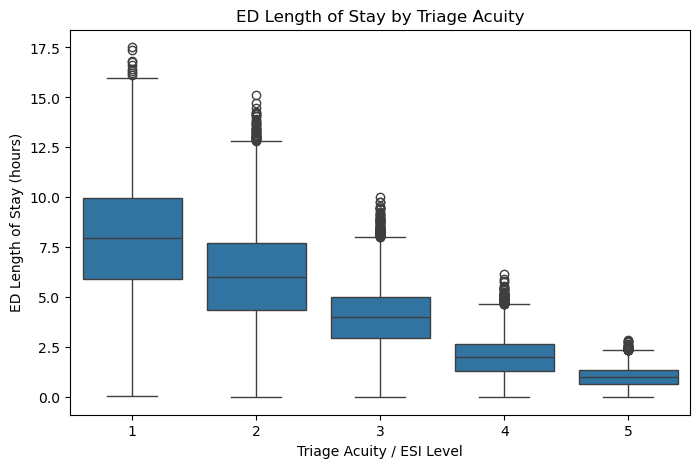

In [16]:
# Plot ED length of stay by ESI level
plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x="triage_acuity", y="ed_los_hours")
plt.title("ED Length of Stay by Triage Acuity")
plt.xlabel("Triage Acuity / ESI Level")
plt.ylabel("ED Length of Stay (hours)")
plt.show()


This boxplot visualizes the relationship between `ed_los_hours` and `triage_acuity`. A clear pattern would suggest that ED length of stay carries strong information about the target, but it is not available at the time of triage.

In [17]:
# Check correlation between ED length of stay and ESI level
ed_los_corr = train[["ed_los_hours", "triage_acuity"]].corr()

ed_los_corr

,ed_los_hours,triage_acuity
ed_los_hours,1.000000,-0.756714
triage_acuity,-0.756714,1.000000


In [18]:
corr_value = train["ed_los_hours"].corr(train["triage_acuity"])
print(f"Correlation between ed_los_hours and triage_acuity: {corr_value:.4f}")

Correlation between ed_los_hours and triage_acuity: -0.7567



This step calculates the correlation between `ed_los_hours` and `triage_acuity`. A strong correlation supports the decision to treat `ed_los_hours` as a leakage feature rather than a valid predictor.

In [19]:
# Distribution of disposition within each ESI level
disposition_by_esi = pd.crosstab(
    train["triage_acuity"],
    train["disposition"],
    normalize="index"
)

disposition_by_esi

disposition,admitted,deceased,discharged,lama,lwbs,observation,transferred
triage_acuity,,,,,,,
1,0.717567,0.082868,0.020795,0.000000,0.000000,0.030416,0.148355
2,0.651388,0.010715,0.122107,0.009301,0.009525,0.079619,0.117345
3,0.382041,0.000000,0.375782,0.038588,0.040766,0.081532,0.081290
4,0.098480,0.000000,0.721503,0.052215,0.068028,0.030104,0.029670
5,0.019214,0.000000,0.863573,0.028163,0.068696,0.010353,0.010002


In [20]:
# Count table of disposition by ESI level
pd.crosstab(train["triage_acuity"], train["disposition"])

disposition,admitted,deceased,discharged,lama,lwbs,observation,transferred
triage_acuity,,,,,,,
1,2312,267,67,0,0,98,478
2,8754,144,1641,125,128,1070,1577
3,11049,0,10868,1116,1179,2358,2351
4,2267,0,16609,1202,1566,693,683
5,219,0,9843,321,783,118,114



This table checks whether final patient disposition is strongly associated with ESI level. Since disposition is usually decided after assessment or treatment, it should not be used as an input feature for triage prediction.

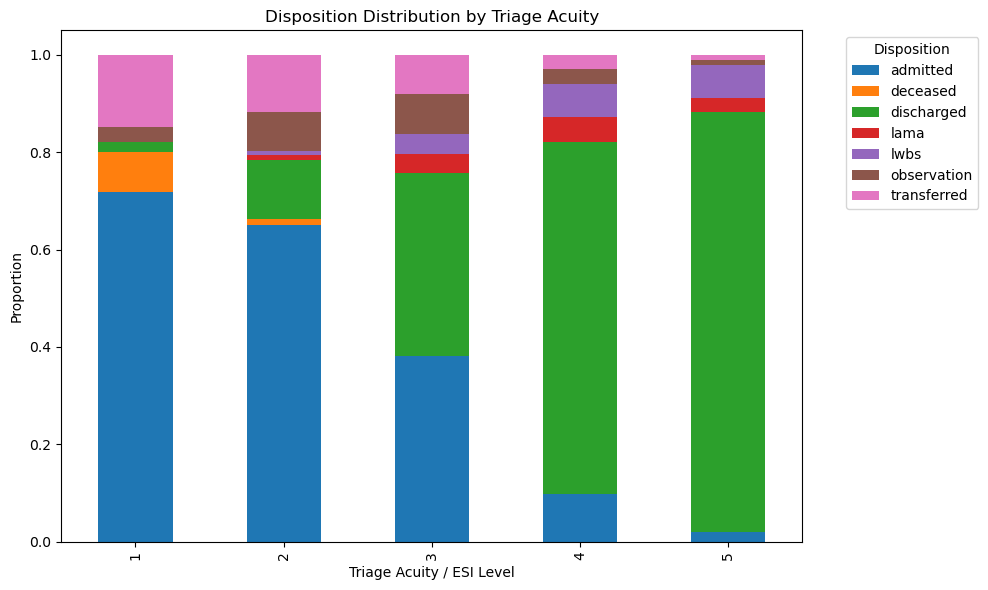

In [21]:
# Plot normalized disposition distribution by ESI level
disposition_by_esi.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Disposition Distribution by Triage Acuity")
plt.xlabel("Triage Acuity / ESI Level")
plt.ylabel("Proportion")
plt.legend(title="Disposition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


This stacked bar chart shows how final disposition varies across ESI levels. Even if disposition is strongly related to acuity, it is post-triage information and should be excluded from model training.

In [22]:
# Define columns that should not be used as model input features
target_col = "triage_acuity"

leakage_cols = [
    "disposition",
    "ed_los_hours"
]

id_cols = [
    "patient_id"
]

exclude_cols = id_cols + leakage_cols + [target_col]

print("Target column:", target_col)
print("Leakage columns:", leakage_cols)
print("ID columns:", id_cols)
print("Columns to exclude from model features:", exclude_cols)

Target column: triage_acuity
Leakage columns: ['disposition', 'ed_los_hours']
ID columns: ['patient_id']
Columns to exclude from model features: ['patient_id', 'disposition', 'ed_los_hours', 'triage_acuity']



This step defines columns that should not be used as model input features. `patient_id` is an identifier, `triage_acuity` is the target variable, and `disposition` and `ed_los_hours` are leakage features.

### Leakage Audit Summary

The leakage audit identifies two train-only variables, `ed_los_hours` and `disposition`, as post-triage outcome variables.

`ed_los_hours` is strongly associated with `triage_acuity`, with a correlation of -0.7567. More urgent patients tend to stay longer in the emergency department. `disposition` also differs strongly by ESI level: high-acuity patients are more likely to be admitted, transferred, or deceased, while low-acuity patients are more likely to be discharged.

However, both variables are only known after the emergency department visit, not at the time of initial triage. Including them in the model would introduce data leakage and produce unrealistically high validation performance.

### Modeling implication

- Use `triage_acuity` only as the target variable.
- Exclude `ed_los_hours` and `disposition` from model features.
- Exclude `patient_id` because it is only an identifier.
- Treat `news2_score` as a clinical score that is likely available at triage if computed from intake vital signs, but test models with and without it in a later ablation study.
- Use `site_id` and `triage_nurse_id` cautiously because they may encode institutional or provider-level practice patterns.

## 4. Target Distribution and Clinical Metric Implications

This section examines the distribution of the target variable `triage_acuity`. Since ESI levels are ordinal and clinically asymmetric, the target distribution directly affects model evaluation. In emergency triage, missing high-acuity patients is more dangerous than overestimating low-acuity patients.

In [24]:
# Count and percentage of each ESI level
target_counts = train["triage_acuity"].value_counts().sort_index()
target_percentages = train["triage_acuity"].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

target_distribution

,count,percentage
triage_acuity,,
1,3222,4.03
2,13439,16.80
3,28921,36.15
4,23020,28.78
5,11398,14.25


This table shows the number and percentage of patients in each ESI level.

In [25]:
# Add clinical meaning for each ESI level
esi_meaning = {
    1: "most urgent / resuscitation",
    2: "high acuity / emergent",
    3: "moderate acuity / urgent",
    4: "low acuity / less urgent",
    5: "least urgent / non-urgent"
}

target_distribution["clinical_meaning"] = target_distribution.index.map(esi_meaning)

target_distribution

,count,percentage,clinical_meaning
triage_acuity,,,
1,3222,4.03,most urgent / resuscitation
2,13439,16.80,high acuity / emergent
3,28921,36.15,moderate acuity / urgent
4,23020,28.78,low acuity / less urgent
5,11398,14.25,least urgent / non-urgent


ESI levels are ordered from 1 to 5, where 1 represents the most urgent cases and 5 represents the least urgent cases.

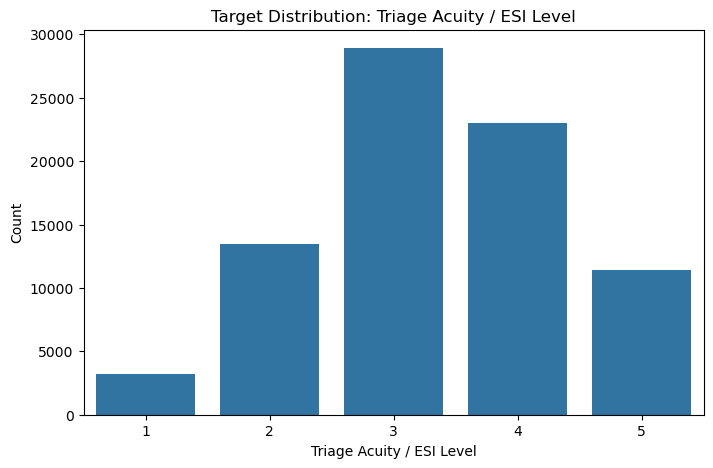

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=train, x="triage_acuity", order=sorted(train["triage_acuity"].unique()))
plt.title("Target Distribution: Triage Acuity / ESI Level")
plt.xlabel("Triage Acuity / ESI Level")
plt.ylabel("Count")
plt.show()

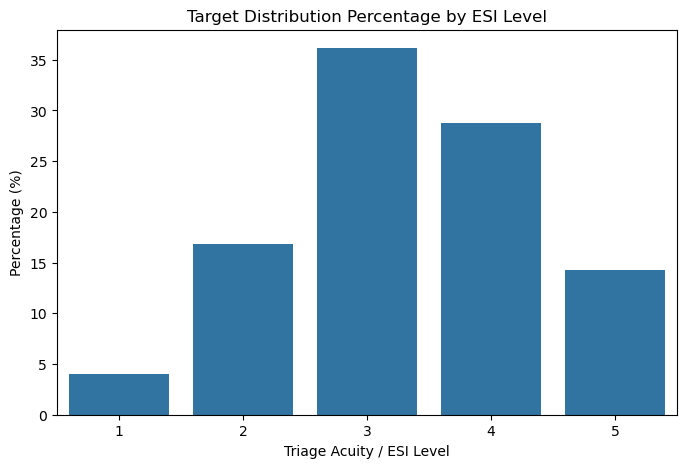

In [27]:
# Plot target percentage distribution
plt.figure(figsize=(8, 5))
sns.barplot(
    x=target_distribution.index,
    y=target_distribution["percentage"]
)
plt.title("Target Distribution Percentage by ESI Level")
plt.xlabel("Triage Acuity / ESI Level")
plt.ylabel("Percentage (%)")
plt.show()

The count plot and percentage plot help identify whether some ESI levels are underrepresented.

In [28]:
# Create a binary high-acuity label for analysis
train["high_acuity"] = train["triage_acuity"].isin([1, 2]).astype(int)

high_acuity_counts = train["high_acuity"].value_counts().sort_index()
high_acuity_percentages = train["high_acuity"].value_counts(normalize=True).sort_index() * 100

high_acuity_distribution = pd.DataFrame({
    "group": ["lower_acuity_ESI_3_4_5", "high_acuity_ESI_1_2"],
    "count": high_acuity_counts.values,
    "percentage": high_acuity_percentages.round(2).values
})

high_acuity_distribution

,group,count,percentage
0,lower_acuity_ESI_3_4_5,63339,79.17
1,high_acuity_ESI_1_2,16661,20.83


This table converts the ordinal ESI target into a binary clinical safety framing: high-acuity patients are ESI 1-2, and lower-acuity patients are ESI 3-5.

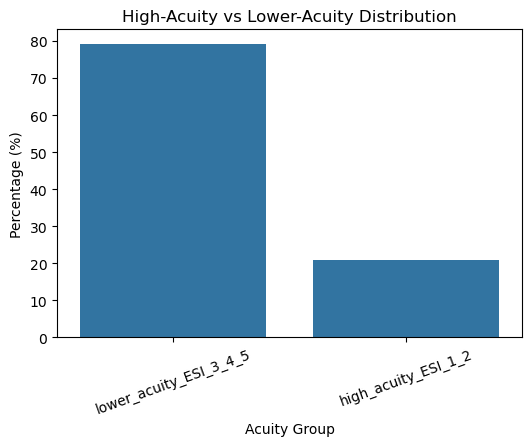

In [29]:
# Plot high-acuity vs lower-acuity distribution
plt.figure(figsize=(6, 4))
sns.barplot(
    data=high_acuity_distribution,
    x="group",
    y="percentage"
)
plt.title("High-Acuity vs Lower-Acuity Distribution")
plt.xlabel("Acuity Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20)
plt.show()

In [30]:
metric_implications = pd.DataFrame([
    {
        "metric": "Accuracy",
        "why_useful": "Simple overall correctness",
        "limitation": "Can hide poor performance on rare high-acuity classes",
        "recommendation": "Report, but do not rely on it alone"
    },
    {
        "metric": "Macro F1",
        "why_useful": "Treats each ESI class equally",
        "limitation": "Does not consider ordinal distance between errors",
        "recommendation": "Use for class imbalance"
    },
    {
        "metric": "Quadratic Weighted Kappa",
        "why_useful": "Accounts for ordinal distance between ESI levels",
        "limitation": "Less intuitive than recall or accuracy",
        "recommendation": "Use as an ordinal-aware metric"
    },
    {
        "metric": "ESI-1 / ESI-2 Recall",
        "why_useful": "Measures whether high-acuity patients are detected",
        "limitation": "Does not measure overtriage burden",
        "recommendation": "Critical for clinical safety"
    },
    {
        "metric": "Dangerous Undertriage Rate",
        "why_useful": "Captures true ESI 1-2 predicted as ESI 3-5",
        "limitation": "Requires predictions, so used after modeling",
        "recommendation": "Use as a key safety metric"
    }
])

metric_implications

,metric,why_useful,limitation,recommendation
0,Accuracy,Simple overall correctness,Can hide poor performance on rare high-acuity ...,"Report, but do not rely on it alone"
1,Macro F1,Treats each ESI class equally,Does not consider ordinal distance between errors,Use for class imbalance
2,Quadratic Weighted Kappa,Accounts for ordinal distance between ESI levels,Less intuitive than recall or accuracy,Use as an ordinal-aware metric
3,ESI-1 / ESI-2 Recall,Measures whether high-acuity patients are dete...,Does not measure overtriage burden,Critical for clinical safety
4,Dangerous Undertriage Rate,Captures true ESI 1-2 predicted as ESI 3-5,"Requires predictions, so used after modeling",Use as a key safety metric


Because ESI is an ordinal clinical label, evaluation should consider both class imbalance and the direction of errors. Undertriage is more dangerous than overtriage.

### Key finding

The target variable `triage_acuity` is an ordinal label ranging from 1 to 5, where lower numbers indicate more urgent patients. The distribution is not uniform across ESI levels, so overall accuracy alone may not be sufficient for evaluation.

From a clinical perspective, the most important risk is undertriage: predicting a truly high-acuity patient as lower acuity. Therefore, later modeling should evaluate not only exact class prediction, but also whether high-acuity patients, especially ESI 1 and ESI 2, are correctly identified.

### Modeling implication

- Treat this as an ordinal multiclass classification problem.
- Also consider a binary high-acuity framing: ESI 1-2 vs ESI 3-5.
- Do not rely only on accuracy.
- Report macro F1 to handle class imbalance.
- Report quadratic weighted kappa to account for ordinal error distance.
- Report ESI-1 recall, ESI-2 recall, and dangerous undertriage rate for clinical safety.

## 5. Missingness as Clinical Workflow Signal

This section analyzes missing values in the dataset. In clinical triage data, missingness should not be treated only as a data quality issue. Some measurements may be missing because they were not clinically necessary or not recorded during a specific workflow. Therefore, missingness itself may contain information about patient acuity.

In [31]:
# Calculate overall missing values in the merged training data
missing_overview = pd.DataFrame({
    "missing_count": train_merged.isna().sum(),
    "missing_percentage": train_merged.isna().mean() * 100
})

missing_overview = (
    missing_overview
    .query("missing_count > 0")
    .sort_values("missing_percentage", ascending=False)
)

missing_overview["missing_percentage"] = missing_overview["missing_percentage"].round(2)

missing_overview

,missing_count,missing_percentage
systolic_bp,4146,5.18
diastolic_bp,4146,5.18
mean_arterial_pressure,4146,5.18
pulse_pressure,4146,5.18
shock_index,4146,5.18
respiratory_rate,3067,3.83
temperature_c,574,0.72



This table shows the number and percentage of missing values for each column in the merged training dataset.

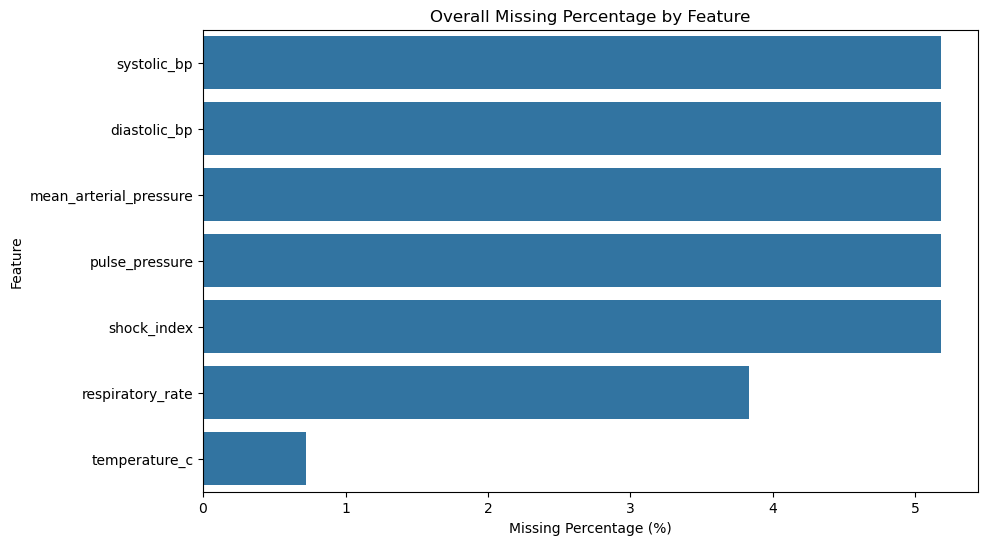

In [32]:
# Plot columns with missing values
plt.figure(figsize=(10, 6))
sns.barplot(
    data=missing_overview.reset_index().rename(columns={"index": "feature"}),
    x="missing_percentage",
    y="feature"
)

plt.title("Overall Missing Percentage by Feature")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")
plt.show()

This bar plot visualizes which features have missing values and how severe the missingness is.

In [33]:
# Define core vital sign columns for missingness analysis
vital_cols = [
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "pain_score",
    "gcs_total",
    "news2_score"
]

# Keep only columns that exist in the dataset
vital_cols = [col for col in vital_cols if col in train_merged.columns]

vital_cols

['systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'respiratory_rate',
 'temperature_c',
 'spo2',
 'pain_score',
 'gcs_total',
 'news2_score']

In [34]:
# Calculate missing percentage of vital signs by ESI level
missing_by_esi = (
    train_merged
    .groupby("triage_acuity")[vital_cols]
    .apply(lambda x: x.isna().mean() * 100)
)

missing_by_esi = missing_by_esi.round(2)

missing_by_esi

,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature_c,spo2,pain_score,gcs_total,news2_score
triage_acuity,,,,,,,,,
1,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0
2,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0
3,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0
4,12.15,12.15,0.0,8.92,0.00,0.0,0.0,0.0,0.0
5,11.84,11.84,0.0,8.90,5.04,0.0,0.0,0.0,0.0



This table shows whether missing values are distributed differently across ESI levels. If lower-acuity patients have more missing vital signs, missingness may reflect clinical workflow rather than random noise.

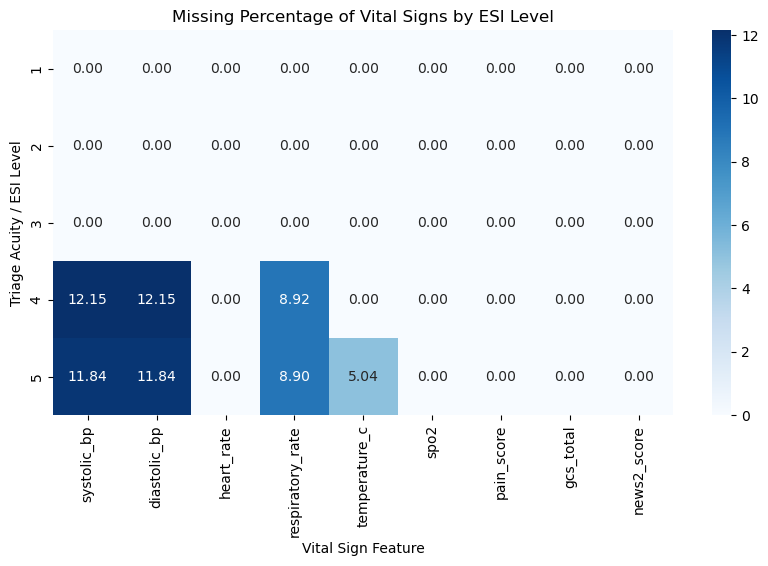

In [35]:
# Visualize missingness by ESI level
plt.figure(figsize=(10, 5))
sns.heatmap(
    missing_by_esi,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Missing Percentage of Vital Signs by ESI Level")
plt.xlabel("Vital Sign Feature")
plt.ylabel("Triage Acuity / ESI Level")
plt.show()

This heatmap helps identify whether missingness patterns differ between high-acuity and low-acuity patients.

In [36]:
# Check pain_score values
train_merged["pain_score"].value_counts(dropna=False).sort_index()

pain_score
-1     11156
 0      1922
 1      4488
 2      4626
 3      7918
 4      8044
 5      8086
 6      7986
 7      8761
 8      5963
 9      5913
 10     5137
Name: count, dtype: int64

In [38]:
# Check whether pain_score = -1 appears differently across ESI levels
pain_minus_one_by_esi = (
    train_merged
    .assign(pain_score_minus_one=(train_merged["pain_score"] == -1))
    .groupby("triage_acuity")["pain_score_minus_one"]
    .mean() * 100
).round(2)

pain_minus_one_by_esi = pain_minus_one_by_esi.to_frame("pain_score_minus_one_percentage")

pain_minus_one_by_esi

,pain_score_minus_one_percentage
triage_acuity,
1,0.00
2,0.00
3,17.95
4,17.44
5,17.11


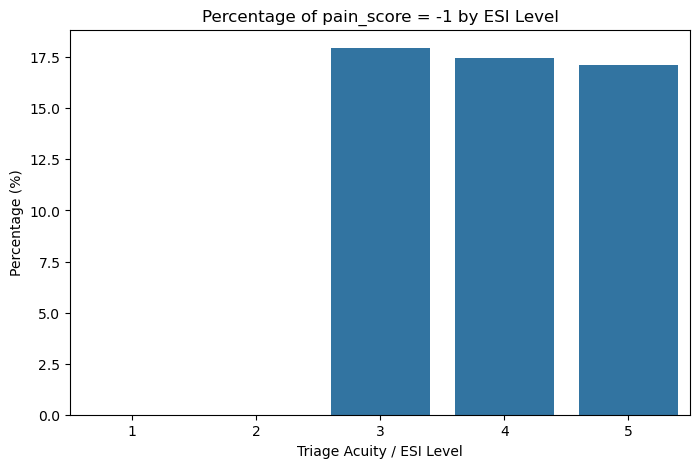

In [39]:
# Plot percentage of pain_score = -1 by ESI level
plt.figure(figsize=(8, 5))
sns.barplot(
    x=pain_minus_one_by_esi.index,
    y=pain_minus_one_by_esi["pain_score_minus_one_percentage"]
)

plt.title("Percentage of pain_score = -1 by ESI Level")
plt.xlabel("Triage Acuity / ESI Level")
plt.ylabel("Percentage (%)")
plt.show()


This step checks whether `pain_score = -1` should be interpreted as a real value or as a special missing code. If this value is concentrated in specific ESI levels, it may reflect documentation or assessment patterns.

In [48]:
pain_score_dist_by_esi = pd.crosstab(
    train_merged["triage_acuity"],
    train_merged["pain_score"],
    normalize="index"
) * 100

pain_score_dist_by_esi.round(2)

pain_score,-1,0,1,2,3,4,5,6,7,8,9,10
triage_acuity,,,,,,,,,,,,
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.43,20.11,19.96,40.50
2,0.00,0.00,0.00,0.00,0.00,0.00,13.97,14.48,14.49,14.45,14.09,28.51
3,17.95,0.00,0.00,0.00,11.66,11.81,11.84,11.33,12.07,11.66,11.67,0.00
4,17.44,0.00,11.50,11.94,11.42,11.88,12.10,12.00,11.72,0.00,0.00,0.00
5,17.11,16.86,16.14,16.48,16.80,16.61,0.00,0.00,0.00,0.00,0.00,0.00


In [40]:
# Count how many vital sign values are missing for each patient
train_merged["missing_vital_count"] = train_merged[vital_cols].isna().sum(axis=1)

# Summary of missing vital count by ESI level
missing_vital_count_by_esi = (
    train_merged
    .groupby("triage_acuity")["missing_vital_count"]
    .describe()
)

missing_vital_count_by_esi

,count,mean,std,min,25%,50%,75%,max
triage_acuity,,,,,,,,
1,3222.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,13439.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
3,28921.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
4,23020.0,0.332103,0.711900,0.0,0.0,0.0,0.0,3.0
5,11398.0,0.376206,0.734874,0.0,0.0,0.0,0.0,4.0


In [43]:
missing_vital_count_dist = pd.crosstab(
    train_merged["triage_acuity"],
    train_merged["missing_vital_count"],
    normalize="index"
) * 100

missing_vital_count_dist.round(2)

missing_vital_count,0,1,2,3,4
triage_acuity,,,,,
1,100.00,0.00,0.00,0.00,0.00
2,100.00,0.00,0.00,0.00,0.00
3,100.00,0.00,0.00,0.00,0.00
4,79.99,7.87,11.09,1.05,0.00
5,76.10,11.69,10.74,1.44,0.04


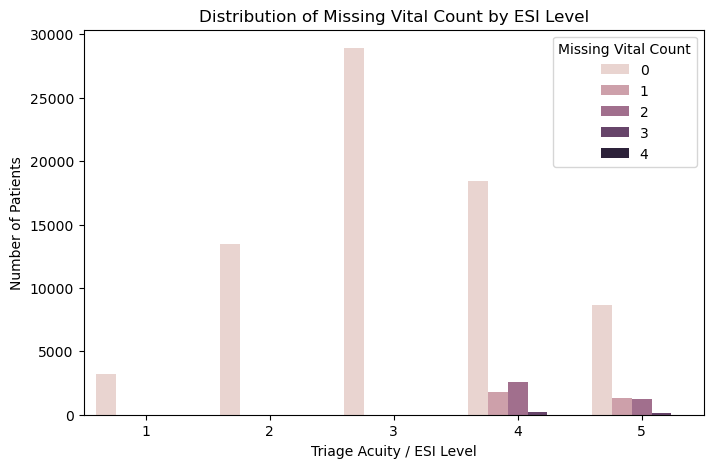

In [42]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_merged,
    x="triage_acuity",
    hue="missing_vital_count"
)

plt.title("Distribution of Missing Vital Count by ESI Level")
plt.xlabel("Triage Acuity / ESI Level")
plt.ylabel("Number of Patients")
plt.legend(title="Missing Vital Count")
plt.show()

In [49]:
# Check missingness by arrival mode if the column exists
if "arrival_mode" in train_merged.columns:
    missing_by_arrival = (
        train_merged
        .groupby("arrival_mode")[vital_cols]
        .apply(lambda x: x.isna().mean() * 100)
        .round(2)
    )
    
    display(missing_by_arrival)

,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature_c,spo2,pain_score,gcs_total,news2_score
arrival_mode,,,,,,,,,
ambulance,5.23,5.23,0.0,3.99,0.68,0.0,0.0,0.0,0.0
brought_by_family,4.87,4.87,0.0,4.05,0.73,0.0,0.0,0.0,0.0
helicopter,5.36,5.36,0.0,3.49,0.67,0.0,0.0,0.0,0.0
police,5.44,5.44,0.0,3.80,0.95,0.0,0.0,0.0,0.0
transfer,5.48,5.48,0.0,3.97,0.78,0.0,0.0,0.0,0.0
walk-in,5.10,5.10,0.0,3.71,0.71,0.0,0.0,0.0,0.0


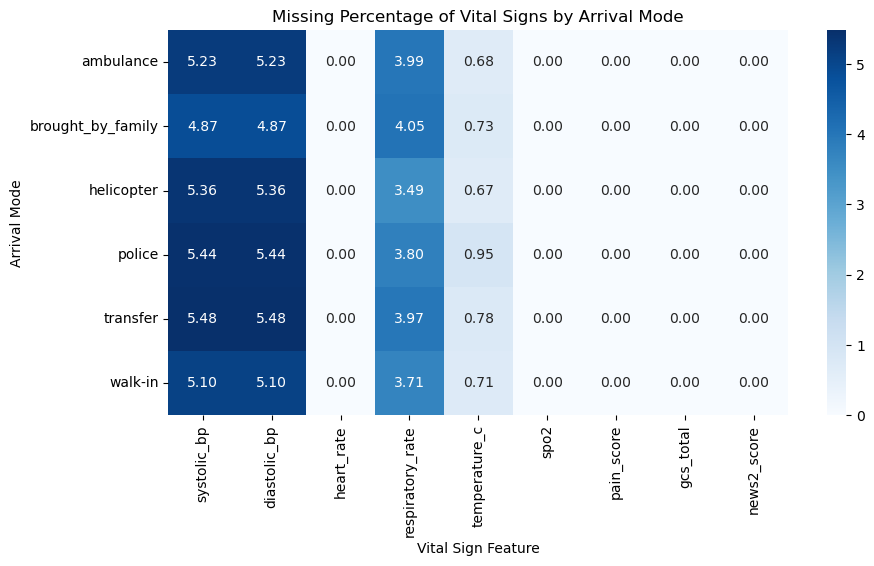

In [50]:
# Visualize missingness by arrival mode
if "arrival_mode" in train_merged.columns:
    plt.figure(figsize=(10, 5))
    sns.heatmap(
        missing_by_arrival,
        annot=True,
        fmt=".2f",
        cmap="Blues"
    )

    plt.title("Missing Percentage of Vital Signs by Arrival Mode")
    plt.xlabel("Vital Sign Feature")
    plt.ylabel("Arrival Mode")
    plt.show()


This check explores whether documentation completeness differs by arrival pathway. For example, ambulance patients may have more complete vital sign records than walk-in patients.

### Key finding

Missingness is not only a data quality issue in this dataset. The missingness pattern should be interpreted as a possible clinical workflow signal.

If vital signs are more complete among ESI 1-2 patients and more frequently missing among ESI 4-5 patients, this suggests that documentation completeness is related to perceived urgency. In that case, missingness indicators may help the model capture workflow patterns associated with triage acuity.

The value `pain_score = -1` should be treated carefully. If it is concentrated in specific ESI levels, it is more likely to represent a special missing or not-assessed code rather than a true pain score.

### Modeling implication

- Do not drop rows with missing vital signs.
- Use imputation for numerical vital signs.
- Add missing indicators for key clinical variables.
- Create `missing_vital_count` as a potential feature.
- Treat `pain_score = -1` as a special missing code or separate indicator.
- Check whether missingness patterns differ across subgroups to avoid biased model behavior.

## 6. Numerical Clinical Features and ESI Severity Gradients

This section examines how numerical clinical features vary across ESI levels. The goal is to identify which structured clinical variables show clear severity gradients and may be useful predictors for triage acuity.

In [51]:
# Define numerical clinical features for EDA
clinical_num_cols = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "news2_score",
    "pain_score_clean",
    "bmi"
]

# Keep only columns that exist in the merged dataset
clinical_num_cols = [col for col in clinical_num_cols if col in train_merged.columns]

clinical_num_cols

['age',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'respiratory_rate',
 'temperature_c',
 'spo2',
 'gcs_total',
 'news2_score',
 'bmi']

In [52]:
# Median values of numerical clinical features by ESI level
num_median_by_esi = (
    train_merged
    .groupby("triage_acuity")[clinical_num_cols]
    .median()
    .round(2)
)

num_median_by_esi

,age,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,news2_score,bmi
triage_acuity,,,,,,,,,,
1,49.0,82.6,52.15,119.2,28.0,38.9,85.9,6.5,14.0,26.1
2,48.0,100.4,63.30,108.7,23.0,38.5,92.0,12.0,10.0,26.0
3,48.0,126.0,76.90,93.0,18.0,37.7,96.0,15.0,2.0,26.0
4,48.0,132.0,80.00,84.1,16.0,37.2,98.0,15.0,0.0,26.1
5,48.0,128.1,78.80,76.8,15.0,36.9,99.0,15.0,0.0,26.1


In [54]:
# Mean values of numerical clinical features by ESI level
num_mean_by_esi = (
    train_merged
    .groupby("triage_acuity")[clinical_num_cols]
    .mean()
    .round(2)
)

num_mean_by_esi

,age,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,news2_score,bmi
triage_acuity,,,,,,,,,,
1,48.69,82.50,51.97,119.29,27.95,38.91,85.86,6.49,13.64,26.44
2,48.63,100.45,63.13,108.71,22.97,38.50,91.88,11.99,10.07,26.34
3,48.56,126.19,76.82,93.02,17.99,37.70,95.87,15.00,2.61,26.32
4,48.60,132.15,79.95,84.09,16.00,37.20,97.82,15.00,0.67,26.38
5,48.25,128.06,78.92,76.99,15.03,36.91,98.92,15.00,0.35,26.42



This table compares the median values of numerical clinical features across ESI levels. Clear monotonic or clinically meaningful changes may indicate strong predictive signals.

In [56]:
core_plot_cols = [
    "news2_score",
    "gcs_total",
    "spo2",
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "temperature_c",
    "pain_score_clean"
]

core_plot_cols = [col for col in core_plot_cols if col in train_merged.columns]

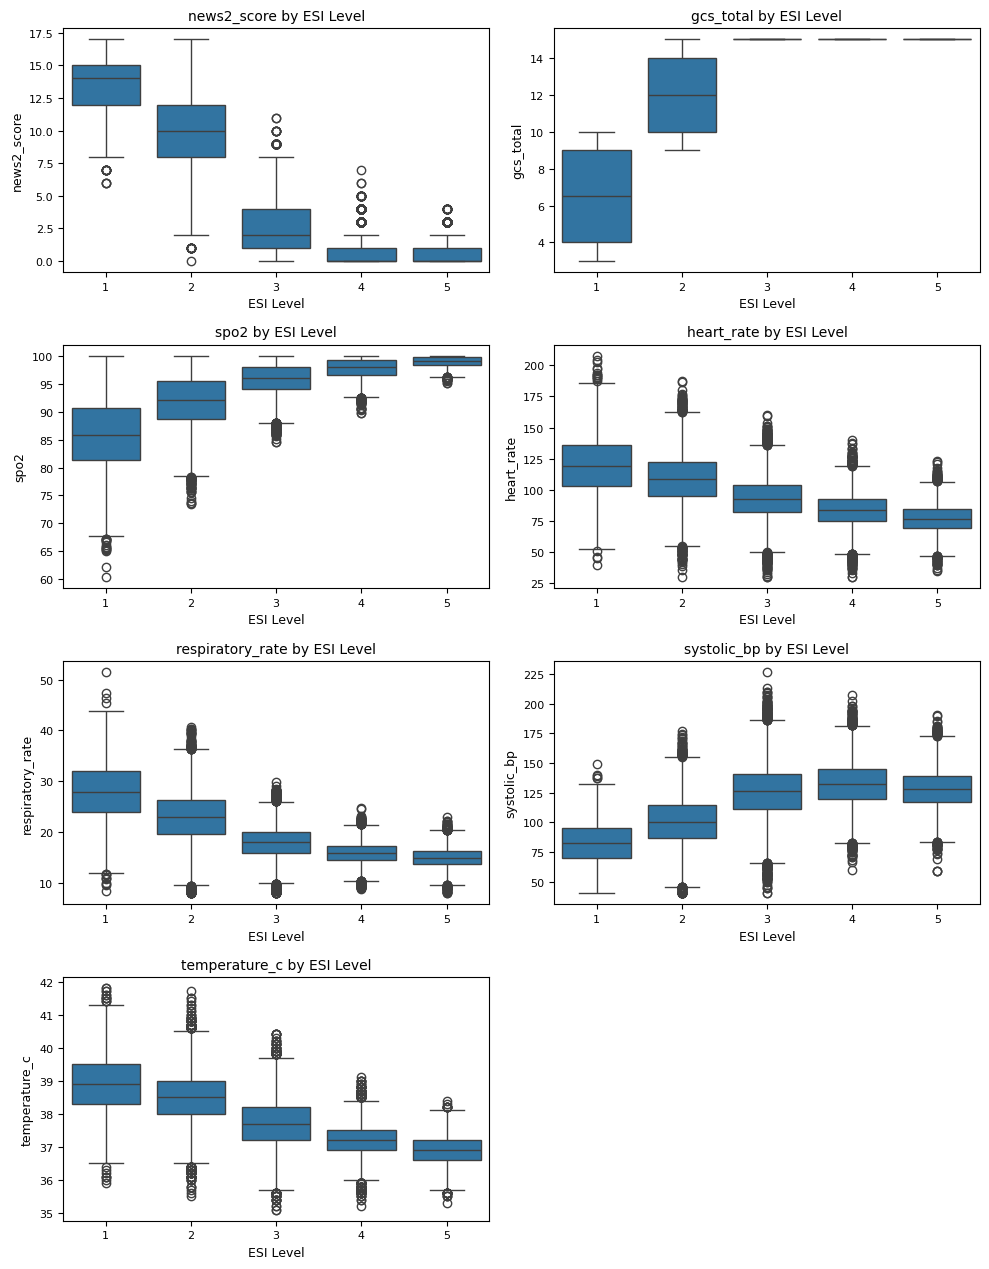

In [58]:
# Plot core clinical features by ESI level in a compact grid
n_cols = 2
n_rows = int(np.ceil(len(core_plot_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 3.2 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(core_plot_cols):
    sns.boxplot(
        data=train_merged,
        x="triage_acuity",
        y=col,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} by ESI Level", fontsize=10)
    axes[i].set_xlabel("ESI Level", fontsize=9)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].tick_params(axis="both", labelsize=8)

# Hide empty subplot if the number of plots is odd
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [65]:
train_merged["severe_pain"] = train_merged["pain_score_clean"] >= 7

In [66]:
# Make sure pain_score_clean exists
if "pain_score_clean" not in train_merged.columns:
    train_merged["pain_score_clean"] = train_merged["pain_score"].replace(-1, np.nan)

# Create severe pain indicator
train_merged["severe_pain"] = train_merged["pain_score_clean"] >= 7

In [69]:
# Make sure pain_score_clean exists
train_merged["pain_score_clean"] = train_merged["pain_score"].replace(-1, np.nan)

# Create clinical warning indicators based on available columns

# Temperature
train_merged["fever"] = train_merged["temperature_c"] >= 38
train_merged["hypothermia"] = train_merged["temperature_c"] < 36

# Heart rate
train_merged["tachycardia"] = train_merged["heart_rate"] >= 100
train_merged["bradycardia"] = train_merged["heart_rate"] < 60

# Respiratory rate
train_merged["tachypnea"] = train_merged["respiratory_rate"] >= 22
train_merged["bradypnea"] = train_merged["respiratory_rate"] < 10

# Oxygen saturation
train_merged["low_spo2"] = train_merged["spo2"] < 94
train_merged["very_low_spo2"] = train_merged["spo2"] < 90

# GCS
train_merged["low_gcs"] = train_merged["gcs_total"] < 15
train_merged["very_low_gcs"] = train_merged["gcs_total"] <= 8

# NEWS2 and pain
train_merged["high_news2"] = train_merged["news2_score"] >= 7
train_merged["severe_pain"] = train_merged["pain_score_clean"] >= 7